# NexTripAI — EDA bộ dữ liệu du lịch đã xác minh

Notebook này phân tích trực tiếp các file `travel_data_verified/*_final.json`. Mục tiêu là kiểm tra quy mô dữ liệu, độ nhất quán metadata, chất lượng trường quan trọng, trùng lặp thực thể và tác động của taxonomy `nightlife` tới GraphRAG.

Nếu môi trường chưa có thư viện EDA, chạy: `%pip install pandas matplotlib seaborn`.

In [1]:
from __future__ import annotations

import json
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.unicode_minus'] = False

DATA_FILES = [
    'attraction_final.json',
    'cafe_final.json',
    'hotel_final.json',
    'nightlife_final.json',
    'restaurant_final.json',
]
candidates = [Path.cwd() / 'travel_data_verified', Path.cwd().parent / 'travel_data_verified']
DATA_DIR = next((path for path in candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Không tìm thấy travel_data_verified. Hãy chạy notebook từ repo NexTripAI-KB.')
print(f'Data directory: {DATA_DIR.resolve()}')

Data directory: D:\FPT\AI17_GRA\NexTripAI\NexTripAI-KB\travel_data_verified


## 1. Nạp dữ liệu và metadata

In [2]:
records: list[dict] = []
metadata_by_type: dict[str, dict] = {}

for filename in DATA_FILES:
    payload = json.loads((DATA_DIR / filename).read_text(encoding='utf-8'))
    entity_type = payload['metadata']['entity_type']
    metadata_by_type[entity_type] = payload['metadata']
    for record in payload['data']:
        records.append({**record, '_source_file': filename})

df = pd.DataFrame(records)
df['source_name'] = df['source'].map(lambda value: value.get('source_name') if isinstance(value, dict) else None)
df['source_url'] = df['source'].map(lambda value: value.get('url') if isinstance(value, dict) else None)
df['lat'] = df['coordinates'].map(lambda value: value.get('lat') if isinstance(value, dict) else None)
df['lng'] = df['coordinates'].map(lambda value: value.get('lng') if isinstance(value, dict) else None)
df['opening_hour'] = df['opening_hours'].map(lambda value: value.get('open') if isinstance(value, dict) else None)
df['closing_hour'] = df['opening_hours'].map(lambda value: value.get('close') if isinstance(value, dict) else None)

print(f'{len(df):,} records × {len(df.columns):,} columns')
df[['id', 'name', 'city', 'entity_type', 'category', 'rating', 'review_count']].head()

692 records × 88 columns


,id,name,city,entity_type,category,rating,review_count
0,attr_qn_001,Eo Gió,Quy Nhơn,attraction,beach,NaN,NaN
1,attr_qn_002,Hòn Khô,Quy Nhơn,attraction,beach,NaN,NaN
2,attr_qn_003,Đồi cát Phương Mai,Quy Nhơn,attraction,natural_attraction,NaN,NaN
3,attr_qn_004,Núi Vũng Chua,Quy Nhơn,attraction,nature,NaN,NaN
4,attr_qn_005,Hòn Sẹo,Quy Nhơn,attraction,beach,NaN,NaN


## 2. Quy mô dataset

,records,unique_ids,cities,categories
entity_type,,,,
restaurant,200,200,2,6
nightlife,195,195,2,6
attraction,118,118,2,30
cafe,106,106,2,10
hotel,73,73,2,5


entity_type,attraction,cafe,hotel,nightlife,restaurant,All
city,,,,,,
Quy Nhơn,51,35,30,96,94,306
Đà Nẵng,67,71,43,99,106,386
All,118,106,73,195,200,692


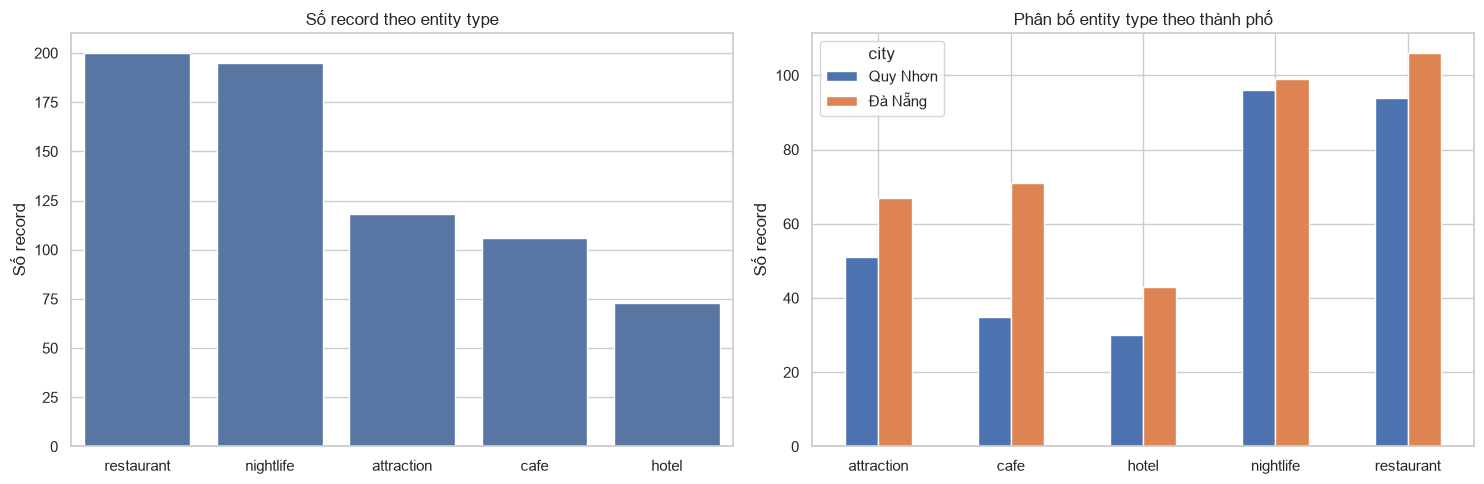

In [3]:
entity_summary = (
    df.groupby('entity_type', observed=True)
      .agg(records=('id', 'size'), unique_ids=('id', 'nunique'), cities=('city', 'nunique'), categories=('category', 'nunique'))
      .sort_values('records', ascending=False)
)
city_entity = pd.crosstab(df['city'], df['entity_type'], margins=True)
display(entity_summary)
display(city_entity)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='entity_type', order=df['entity_type'].value_counts().index, ax=axes[0])
axes[0].set(title='Số record theo entity type', xlabel='', ylabel='Số record')
pd.crosstab(df['entity_type'], df['city']).plot(kind='bar', ax=axes[1])
axes[1].set(title='Phân bố entity type theo thành phố', xlabel='', ylabel='Số record')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Audit metadata: khai báo so với dữ liệu thực tế

In [4]:
def nonempty(value: object) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and pd.isna(value):
        return False
    if isinstance(value, (str, list, dict)):
        return bool(value)
    return True

audit_rows = []
for entity_type, metadata in metadata_by_type.items():
    subset = df[df['entity_type'] == entity_type]
    actual_city = subset['city'].value_counts()
    audit_rows.append({
        'entity_type': entity_type,
        'declared_total': metadata.get('total_count'),
        'actual_total': len(subset),
        'declared_quy_nhon': metadata.get('quy_nhon_count'),
        'actual_quy_nhon': int(actual_city.get('Quy Nhơn', 0)),
        'declared_da_nang': metadata.get('da_nang_count'),
        'actual_da_nang': int(actual_city.get('Đà Nẵng', 0)),
        'declared_geocoded': metadata.get('geocoded_count'),
        'actual_coordinates': int((subset['lat'].notna() & subset['lng'].notna()).sum()),
        'declared_crawled': metadata.get('crawled_count'),
        'actual_last_crawled': int(subset.get('last_crawled', pd.Series(index=subset.index, dtype=object)).map(nonempty).sum()),
        'declared_verified': metadata.get('verified_count'),
        'actual_last_verified': int(subset.get('last_verified', pd.Series(index=subset.index, dtype=object)).map(nonempty).sum()),
    })
metadata_audit = pd.DataFrame(audit_rows).set_index('entity_type')
metadata_audit

,declared_total,actual_total,declared_quy_nhon,actual_quy_nhon,declared_da_nang,actual_da_nang,declared_geocoded,actual_coordinates,declared_crawled,actual_last_crawled,declared_verified,actual_last_verified
entity_type,,,,,,,,,,,,
attraction,118,118,51,51,67,67,118,115,NaN,0,118.0,5
cafe,106,106,35,35,71,71,106,106,106.0,106,NaN,4
hotel,73,73,30,30,43,43,73,73,73.0,73,NaN,73
nightlife,195,195,96,96,99,99,39,195,39.0,195,NaN,195
restaurant,200,200,94,94,106,106,200,200,188.0,200,NaN,200


In [5]:
metadata_mismatches = []
for entity_type, row in metadata_audit.iterrows():
    for declared, actual in [
        ('declared_total', 'actual_total'),
        ('declared_quy_nhon', 'actual_quy_nhon'),
        ('declared_da_nang', 'actual_da_nang'),
        ('declared_geocoded', 'actual_coordinates'),
        ('declared_crawled', 'actual_last_crawled'),
        ('declared_verified', 'actual_last_verified'),
    ]:
        if pd.notna(row[declared]) and row[declared] != row[actual]:
            metadata_mismatches.append({
                'entity_type': entity_type,
                'metric': declared.removeprefix('declared_'),
                'declared': row[declared],
                'actual': row[actual],
                'delta': row[actual] - row[declared],
            })
metadata_mismatches_df = pd.DataFrame(metadata_mismatches)
metadata_mismatches_df

,entity_type,metric,declared,actual,delta
0,attraction,geocoded,118.0,115.0,-3.0
1,attraction,verified,118.0,5.0,-113.0
2,nightlife,geocoded,39.0,195.0,156.0
3,nightlife,crawled,39.0,195.0,156.0
4,restaurant,crawled,188.0,200.0,12.0


## 4. Chất lượng các trường quan trọng

In [6]:
quality = (
    df.assign(
        missing_address=df['address'].isna() | df['address'].astype(str).str.strip().eq(''),
        missing_coordinates=df['lat'].isna() | df['lng'].isna(),
        missing_source=df['source_url'].isna() | df['source_url'].astype(str).str.strip().eq(''),
        missing_rating=df['rating'].isna() | df['rating'].eq(0),
        missing_reviews=df['review_count'].isna() | df['review_count'].eq(0),
        missing_opening=df['opening_hour'].isna() & df['closing_hour'].isna(),
        missing_last_verified=~df.get('last_verified', pd.Series(index=df.index, dtype=object)).map(nonempty),
    )
    .groupby('entity_type')[[
        'missing_address', 'missing_coordinates', 'missing_source', 'missing_rating',
        'missing_reviews', 'missing_opening', 'missing_last_verified'
    ]]
    .sum()
    .astype(int)
)
quality.loc['TOTAL'] = quality.sum()
quality

,missing_address,missing_coordinates,missing_source,missing_rating,missing_reviews,missing_opening,missing_last_verified
entity_type,,,,,,,
attraction,0,3,0,58,116,68,113
cafe,0,0,0,59,105,0,102
hotel,0,0,0,56,57,0,0
nightlife,0,0,0,195,195,0,0
restaurant,0,0,0,113,197,7,0
TOTAL,0,3,0,481,670,75,215


In [7]:
missing_coordinates = df.loc[df['lat'].isna() | df['lng'].isna(), ['id', 'name', 'city', 'entity_type', 'address']]
display(Markdown(f'**Record thiếu tọa độ: {len(missing_coordinates)}**'))
missing_coordinates

**Record thiếu tọa độ: 3**

,id,name,city,entity_type,address
49,attr_qn_050,Đảo Yến Quy nhơn,Quy Nhơn,attraction,Không xác định được một địa điểm du lịch độc lập tương ứng với tên và mô tả trong dữ liệu gốc.
79,attr_dn_028,Giếng trời,Đà Nẵng,attraction,"Khu bảo tồn thiên nhiên Bà Nà – Núi Chúa, Đà Nẵng, Việt Nam"
114,attr_dn_063,Cây đa nghìn năm,Đà Nẵng,attraction,"Bán đảo Sơn Trà, phường Sơn Trà, Đà Nẵng, Việt Nam"


## 5. Phát hiện trùng địa điểm

In [8]:
def normalize_name(value: object) -> str:
    text = unicodedata.normalize('NFKD', str(value).strip().casefold()).replace('đ', 'd')
    text = ''.join(char for char in text if not unicodedata.combining(char))
    return re.sub(r'[^a-z0-9]+', ' ', text).strip()

df['normalized_name'] = df['name'].map(normalize_name)
df['identity_key'] = df['city'].astype(str) + '|' + df['normalized_name']
duplicate_sizes = df.groupby('identity_key').size().rename('records')
duplicate_keys = duplicate_sizes[duplicate_sizes > 1].index
duplicates = (
    df[df['identity_key'].isin(duplicate_keys)]
      .sort_values(['identity_key', 'entity_type', 'id'])
      [['identity_key', 'id', 'name', 'city', 'entity_type', 'category', 'address']]
)
duplicate_summary = pd.Series({
    'duplicate_groups': len(duplicate_keys),
    'records_in_duplicate_groups': len(duplicates),
    'extra_records_beyond_one_per_group': len(duplicates) - len(duplicate_keys),
    'unique_city_name_identities': df['identity_key'].nunique(),
})
display(duplicate_summary.to_frame('value'))
duplicates.head(30)

,value
duplicate_groups,88
records_in_duplicate_groups,177
extra_records_beyond_one_per_group,89
unique_city_name_identities,603


,identity_key,id,name,city,entity_type,category,address
132,Quy Nhơn|a merci cafe brunch,cafe_qn_016,À Merci Cafe & Brunch,Quy Nhơn,cafe,cafe,"Lô 70 Lê Đức Thọ, Quy Nhơn, Gia Lai, Việt Nam"
317,Quy Nhơn|a merci cafe brunch,night_qn_023,À Merci Cafe & Brunch,Quy Nhơn,nightlife,late_night_cafe,"Lô 70 Lê Đức Thọ, Quy Nhơn, Gia Lai, Việt Nam"
149,Quy Nhơn|alice cafe,cafe_qn_033,Alice Cafe,Quy Nhơn,cafe,tea_shop,"286-288 Hùng Vương, Quy Nhơn, Gia Lai, Việt Nam"
328,Quy Nhơn|alice cafe,night_qn_034,Alice Cafe,Quy Nhơn,nightlife,late_night_cafe,"286-288 Hùng Vương, Quy Nhơn, Gia Lai, Việt Nam"
367,Quy Nhơn|banh beo ba xe,night_qn_074,Bánh bèo Bà Xê,Quy Nhơn,nightlife,late_night_dining,"62A Phan Thúc Trực, Quy Nhơn Đông, Gia Lai"
532,Quy Nhơn|banh beo ba xe,rest_qn_057,Bánh bèo Bà Xê,Quy Nhơn,restaurant,vietnamese,"62A phan thúc trực, phường quy nhơn đông( cầu, Lê Thanh Nghị, Quy Nhơn Đông, Gia Lai, Việt Nam)"
349,Quy Nhơn|banh canh banh cuon tu u,night_qn_056,"Bánh canh, Bánh cuốn Tư Ù",Quy Nhơn,nightlife,late_night_dining,"11 Ngọc Hân Công Chúa, Quy Nhơn, Gia Lai, Việt Nam"
529,Quy Nhơn|banh canh banh cuon tu u,rest_qn_054,"Bánh canh, Bánh cuốn Tư Ù",Quy Nhơn,restaurant,vietnamese,"11 Ngọc Hân Công Chúa, Quy Nhơn, Gia Lai, Việt Nam"
346,Quy Nhơn|banh mi 555,night_qn_053,Bánh mì 555,Quy Nhơn,nightlife,late_night_dining,"553 Trần Hưng Đạo, Quy Nhơn, Gia Lai, Việt Nam"
526,Quy Nhơn|banh mi 555,rest_qn_051,Bánh mì 555,Quy Nhơn,restaurant,vietnamese,"553 Trần Hưng Đạo, Quy Nhơn, Gia Lai, Việt Nam"


## 6. Phân tích riêng taxonomy nightlife

,records,duplicates_other_entity,duplicate_rate_pct
category,,,
late_night_dining,98,57,58.2
late_night_cafe,61,27,44.3
bar,16,1,6.2
nightclub,7,0,0.0
pub,7,0,0.0
rooftop_bar,6,0,0.0


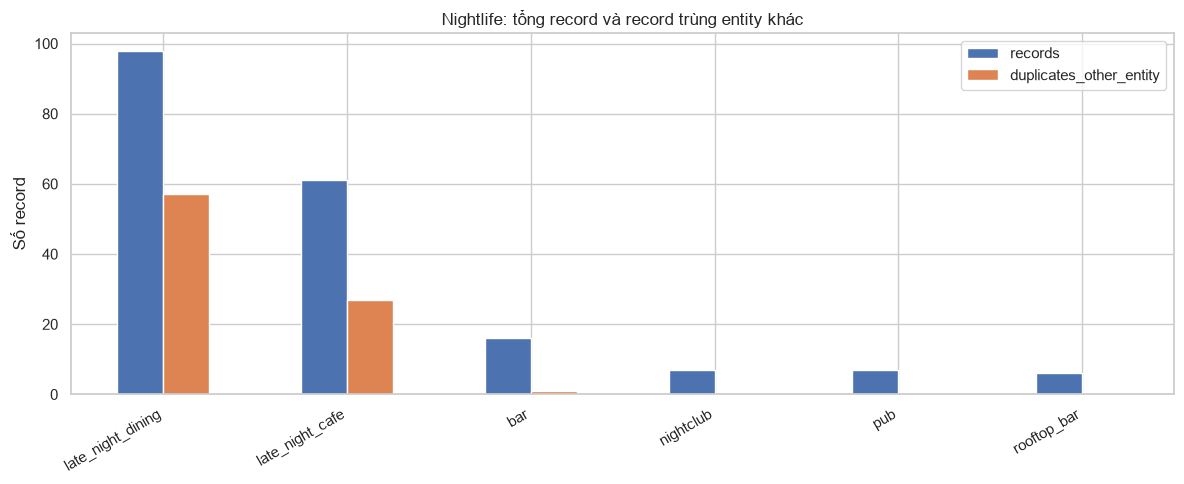

In [9]:
nightlife = df[df['entity_type'] == 'nightlife'].copy()
non_nightlife_keys = set(df.loc[df['entity_type'] != 'nightlife', 'identity_key'])
nightlife['duplicates_another_entity'] = nightlife['identity_key'].isin(non_nightlife_keys)
nightlife_taxonomy = (
    nightlife.groupby('category', observed=True)
      .agg(records=('id', 'size'), duplicates_other_entity=('duplicates_another_entity', 'sum'))
      .sort_values('records', ascending=False)
)
nightlife_taxonomy['duplicate_rate_pct'] = (
    nightlife_taxonomy['duplicates_other_entity'] / nightlife_taxonomy['records'] * 100
).round(1)
display(nightlife_taxonomy)

ax = nightlife_taxonomy[['records', 'duplicates_other_entity']].plot(kind='bar', figsize=(12, 5))
ax.set(title='Nightlife: tổng record và record trùng entity khác', xlabel='', ylabel='Số record')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [10]:
nightlife_overlap = nightlife.loc[
    nightlife['duplicates_another_entity'],
    ['id', 'name', 'city', 'category', 'address', 'identity_key'],
].merge(
    df.loc[df['entity_type'] != 'nightlife', ['id', 'entity_type', 'category', 'identity_key']],
    on='identity_key',
    how='left',
    suffixes=('_nightlife', '_original'),
)
nightlife_overlap.head(30)

,id_nightlife,name,city,category_nightlife,address,identity_key,id_original,entity_type,category_original
0,night_qn_019,SEASAND COFFEE LOUNGE,Quy Nhơn,late_night_cafe,"Đối diện 360 Xuân Diệu, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|seasand coffee lounge,cafe_qn_008,cafe,rooftop_cafe
1,night_qn_021,Bốn Mùa,Quy Nhơn,late_night_cafe,"Đường Xuân Diệu, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|bon mua,cafe_qn_012,cafe,cafe
2,night_qn_023,À Merci Cafe & Brunch,Quy Nhơn,late_night_cafe,"Lô 70 Lê Đức Thọ, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|a merci cafe brunch,cafe_qn_016,cafe,cafe
3,night_qn_026,Phạm House,Quy Nhơn,late_night_cafe,"8 Ngô Mây, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|pham house,cafe_qn_036,cafe,tea_shop
4,night_qn_027,Brownie Coffee,Quy Nhơn,late_night_cafe,"65 Lê Lợi, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|brownie coffee,cafe_qn_020,cafe,work_cafe
5,night_qn_028,Capu Coffee,Quy Nhơn,late_night_cafe,"122B Nguyễn Thị Định, Quy Nhơn Nam, Gia Lai, Việt Nam",Quy Nhơn|capu coffee,cafe_qn_019,cafe,cafe
6,night_qn_029,Namto House Coffee,Quy Nhơn,late_night_cafe,"Lô 33 Nguyễn Thị Định, Quy Nhơn Nam, Gia Lai, Việt Nam",Quy Nhơn|namto house coffee,cafe_qn_014,cafe,cafe
7,night_qn_032,YQ Cafe,Quy Nhơn,late_night_cafe,"18 Trần Văn Ơn, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|yq cafe,cafe_qn_001,cafe,cafe
8,night_qn_034,Alice Cafe,Quy Nhơn,late_night_cafe,"286-288 Hùng Vương, Quy Nhơn, Gia Lai, Việt Nam",Quy Nhơn|alice cafe,cafe_qn_033,cafe,tea_shop
9,night_qn_036,Marina Garden,Quy Nhơn,late_night_cafe,"Đối diện 188 Nguyễn Thị Định, Quy Nhơn Nam, Gia Lai, Việt Nam",Quy Nhơn|marina garden,cafe_qn_022,cafe,cafe


## 7. Category, rating, review và nguồn

,entity_type,category,records
23,attraction,nature,21
9,attraction,entertainment,17
2,attraction,beach,14
21,attraction,natural_attraction,12
10,attraction,historical,11
6,attraction,culture,10
26,attraction,religious_site,6
5,attraction,cultural_attraction,3
13,attraction,historical_site,3
0,attraction,agritourism_area,1


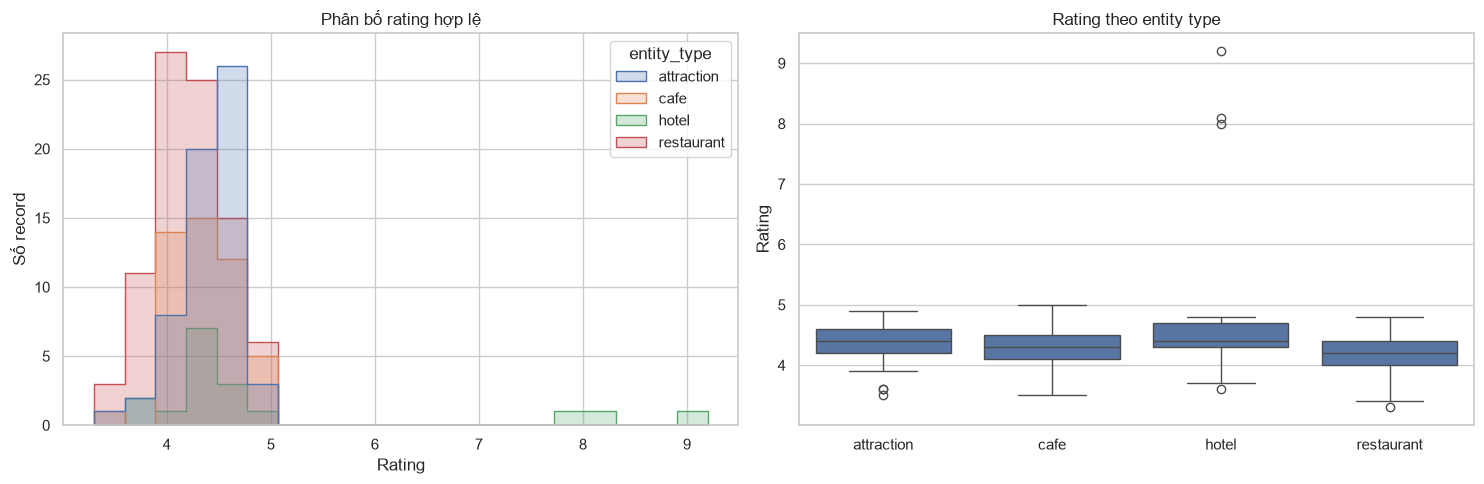

In [11]:
category_counts = (
    df.groupby(['entity_type', 'category'], observed=True).size()
      .rename('records').reset_index()
      .sort_values(['entity_type', 'records'], ascending=[True, False])
)
display(category_counts.groupby('entity_type').head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
valid_ratings = df.loc[df['rating'].notna() & df['rating'].gt(0)]
sns.histplot(data=valid_ratings, x='rating', hue='entity_type', bins=20, element='step', ax=axes[0])
axes[0].set(title='Phân bố rating hợp lệ', xlabel='Rating', ylabel='Số record')
sns.boxplot(data=valid_ratings, x='entity_type', y='rating', ax=axes[1])
axes[1].set(title='Rating theo entity type', xlabel='', ylabel='Rating')
plt.tight_layout()
plt.show()

In [12]:
source_summary = (
    df.groupby('source_name', dropna=False)
      .agg(records=('id', 'size'), entity_types=('entity_type', 'nunique'), cities=('city', 'nunique'))
      .sort_values('records', ascending=False)
)
source_summary.head(20)

,records,entity_types,cities
source_name,,,
daivietourist.vn,146,4,1
vinwonders.com,91,3,2
mia.vn,64,4,2
quynhonguide.com,44,2,1
ivivu.com,39,3,2
mia,37,1,2
foody.vn,22,3,2
divui,20,1,1
foodhunter.vn,19,2,1


## 8. Kiểm tra tọa độ

,id,name,city,entity_type,lat,lng,address
49,attr_qn_050,Đảo Yến Quy nhơn,Quy Nhơn,attraction,NaN,NaN,Không xác định được một địa điểm du lịch độc lập tương ứng với tên và mô tả trong dữ liệu gốc.
79,attr_dn_028,Giếng trời,Đà Nẵng,attraction,NaN,NaN,"Khu bảo tồn thiên nhiên Bà Nà – Núi Chúa, Đà Nẵng, Việt Nam"
114,attr_dn_063,Cây đa nghìn năm,Đà Nẵng,attraction,NaN,NaN,"Bán đảo Sơn Trà, phường Sơn Trà, Đà Nẵng, Việt Nam"


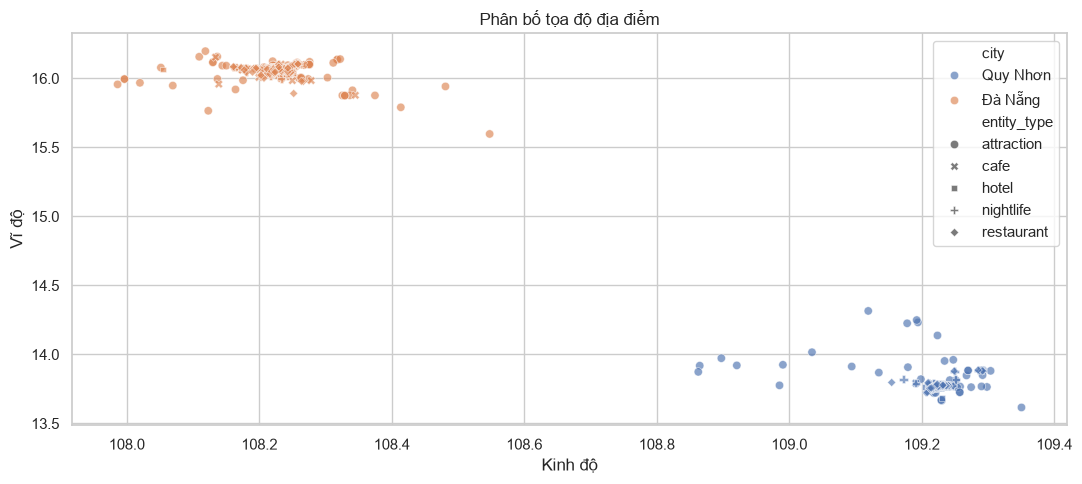

In [13]:
coordinate_issues = df[
    df['lat'].isna() | df['lng'].isna()
    | ~df['lat'].between(8, 24, inclusive='both')
    | ~df['lng'].between(102, 110.8, inclusive='both')
][['id', 'name', 'city', 'entity_type', 'lat', 'lng', 'address']]
display(coordinate_issues)

coords = df.dropna(subset=['lat', 'lng'])
sns.scatterplot(data=coords, x='lng', y='lat', hue='city', style='entity_type', alpha=0.65)
plt.title('Phân bố tọa độ địa điểm')
plt.xlabel('Kinh độ')
plt.ylabel('Vĩ độ')
plt.tight_layout()
plt.show()

## 9. Kết luận tự động và khuyến nghị cho GraphRAG

In [14]:
nightlife_duplicates = int(nightlife['duplicates_another_entity'].sum())
late_night_count = int(nightlife['category'].isin(['late_night_dining', 'late_night_cafe']).sum())
missing_rating = int((df['rating'].isna() | df['rating'].eq(0)).sum())
missing_verified = int((~df.get('last_verified', pd.Series(index=df.index, dtype=object)).map(nonempty)).sum())

report = f'''
### Kết quả chính

- Dataset có **{len(df):,} record**, nhưng chỉ có **{df['identity_key'].nunique():,} identity theo city + tên chuẩn hóa**.
- Có **{len(duplicate_keys):,} nhóm trùng tên**, tạo ra **{len(duplicates) - len(duplicate_keys):,} record dư** nếu mỗi địa điểm vật lý chỉ nên có một node.
- Nightlife có **{len(nightlife):,} record**; **{late_night_count:,}** là `late_night_dining/cafe` và **{nightlife_duplicates:,}** trùng với entity khác.
- **{missing_rating:,}/{len(df):,}** record thiếu rating hữu ích (`null` hoặc `0`).
- **{missing_verified:,}/{len(df):,}** record chưa có `last_verified`.
- Có **{len(missing_coordinates):,}** record thiếu tọa độ và **{len(metadata_mismatches_df):,}** chỉ số metadata không khớp dữ liệu hiện tại.

### Khuyến nghị

1. Dùng một node `Place` cho một địa điểm vật lý; biểu diễn mở khuya bằng concept/edge như `OPEN_LATE` thay vì nhân bản node nightlife.
2. Tạo `dataset_version`, `schema_version`, `generated_at`, checksum và quality counters từ dữ liệu thực tế trong cùng pipeline build.
3. Không dùng rating bằng `0` như rating thật; chuẩn hóa thành `null` và tách `rating_missing`.
4. Chặn deploy nếu ID trùng, city count sai, metadata lệch hoặc duplicate identity vượt ngưỡng.
5. Chạy lại benchmark aggregate/recommendation sau dedup vì count và phân bố entity type sẽ thay đổi.
'''
display(Markdown(report))


### Kết quả chính

- Dataset có **692 record**, nhưng chỉ có **603 identity theo city + tên chuẩn hóa**.
- Có **88 nhóm trùng tên**, tạo ra **89 record dư** nếu mỗi địa điểm vật lý chỉ nên có một node.
- Nightlife có **195 record**; **159** là `late_night_dining/cafe` và **85** trùng với entity khác.
- **481/692** record thiếu rating hữu ích (`null` hoặc `0`).
- **215/692** record chưa có `last_verified`.
- Có **3** record thiếu tọa độ và **5** chỉ số metadata không khớp dữ liệu hiện tại.

### Khuyến nghị

1. Dùng một node `Place` cho một địa điểm vật lý; biểu diễn mở khuya bằng concept/edge như `OPEN_LATE` thay vì nhân bản node nightlife.
2. Tạo `dataset_version`, `schema_version`, `generated_at`, checksum và quality counters từ dữ liệu thực tế trong cùng pipeline build.
3. Không dùng rating bằng `0` như rating thật; chuẩn hóa thành `null` và tách `rating_missing`.
4. Chặn deploy nếu ID trùng, city count sai, metadata lệch hoặc duplicate identity vượt ngưỡng.
5. Chạy lại benchmark aggregate/recommendation sau dedup vì count và phân bố entity type sẽ thay đổi.
